# Peptide/Variant-Level Differential Abundance

This notebook performs the analysis for the selected model-derived peptide features. It:

1. Loads the severe vs non-severe peptide abundance matrix.
2. Extracts the top L1 logistic-regression peptide features.
3. Assesses missingness for those top peptides.
4. Performs severe vs non-severe differential abundance tests.
5. Creates intensity plots for the 1st, 2nd, and 6th ranked peptides.
6. Compares the selected modified peptide variants against the least-modified or most abundant alternative variant with the same amino-acid sequence.

Run this notebook in the same folder as `variants_filtered.tsv` and the `models/` directory produced by `modeling2.ipynb`. If `variants_filtered.tsv` is missing but `variants_tmt.tsv` exists, the notebook will recreate `variants_filtered.tsv`.

In [ ]:
from pathlib import Path
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu, ttest_ind

warnings.filterwarnings("ignore", category=RuntimeWarning)

OUTPUT_DIR = Path("peptide_differentials")
OUTPUT_DIR.mkdir(exist_ok=True)

TOP_N_FEATURES = 20
# Use the 1st, 2nd, and 6th ranked model-derived peptides for Section 3 plots/reporting.
SELECTED_FEATURE_RANKS = [1, 2, 6]
TOP_N_PLOTS = len(SELECTED_FEATURE_RANKS)

LABEL_MAP = {"Non-severe-COVID-19": 0, "Severe-COVID-19": 1}

print("Output directory:", OUTPUT_DIR.resolve())

Output directory: /Users/kailey/Downloads/cse291b-covid19/section3_outputs


## 1. Load or recreate the severe vs non-severe abundance matrix

Rows are patients. Columns are peptide/variant abundance intensities. The final `Condition` column stores the class label.

In [2]:
filtered_path = Path("variants_filtered.tsv")
raw_path = Path("variants_tmt.tsv")

if filtered_path.exists():
    df = pd.read_csv(filtered_path, sep="\t", index_col=0)
    print("Loaded variants_filtered.tsv")
elif raw_path.exists():
    print("variants_filtered.tsv was not found. Recreating it from variants_tmt.tsv...")
    variants = pd.read_csv(raw_path, sep="\t", low_memory=False)
    intensity_cols = [c for c in variants.columns if "intensity_for_peptide_variant" in c]
    real_patient_cols = [
        c for c in intensity_cols
        if not c.startswith("_dyn_#Empty") and not c.startswith("_dyn_#Norm")
    ]
    df = variants[["Peptide"] + real_patient_cols].replace(0.0, np.nan)
    df = df.set_index("Peptide").T
    df.index = df.index.map(lambda x: ".".join(x.replace("_dyn_#", "").split(".")[:2]))
    df["Condition"] = df.index.map(lambda x: x.split(".")[0])
    df = df[df["Condition"].isin(["Severe-COVID-19", "Non-severe-COVID-19"])]
    df.to_csv(filtered_path, sep="\t")
    print("Saved variants_filtered.tsv")
else:
    raise FileNotFoundError("Need either variants_filtered.tsv or variants_tmt.tsv in this folder.")

condition = df["Condition"]
X = df.drop(columns=["Condition"]).apply(pd.to_numeric, errors="coerce")

print(f"Patients: {X.shape[0]}")
print(f"Peptide/variant features: {X.shape[1]:,}")
print("\nCondition counts:")
print(condition.value_counts())

Loaded variants_filtered.tsv
Patients: 43
Peptide/variant features: 101,461

Condition counts:
Condition
Non-severe-COVID-19    25
Severe-COVID-19        18
Name: count, dtype: int64


## 2. Extract top L1 logistic-regression features

The feature-importance plot identifies model-relevant peptides. This step loads the saved model and selected peptide list, then extracts the largest absolute logistic-regression coefficients.

In [3]:
import joblib

MODEL_DIR = Path("models")
model_path = MODEL_DIR / "modeling2_best_model.joblib"
selected_path = MODEL_DIR / "modeling2_selected_peptides.txt"

if not model_path.exists() or not selected_path.exists():
    raise FileNotFoundError(
        "Could not find the saved model artifacts. Run modeling2.ipynb first, or place "
        "models/modeling2_best_model.joblib and models/modeling2_selected_peptides.txt in this folder."
    )

pipeline = joblib.load(model_path)
selected_peptides = pd.read_csv(selected_path, header=None)[0].tolist()

model = pipeline.named_steps["model"]
coefs = model.coef_[0]

feature_importance = (
    pd.DataFrame({
        "Peptide": selected_peptides,
        "coefficient": coefs,
        "abs_coefficient": np.abs(coefs),
        "model_direction": np.where(coefs > 0, "Higher in severe by model", "Higher in non-severe by model")
    })
    .sort_values("abs_coefficient", ascending=False)
    .reset_index(drop=True)
)

# Keep only features that are actually present in X.
feature_importance = feature_importance[feature_importance["Peptide"].isin(X.columns)].reset_index(drop=True)
top_features = feature_importance.head(TOP_N_FEATURES).copy()

top_features.to_csv(OUTPUT_DIR / "top_model_features.tsv", sep="\t", index=False)
display(top_features.head(20))

/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:376: InconsistentVersionWarning: Trying to unpickle estimator SimpleImputer from version 1.6.1 when using version 1.5.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:376: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.6.1 when using version 1.5.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:376: InconsistentVersionWarning: Trying to unpickle estimator LogisticRegression from version 1.6.1 when using version 1.5.1. This might lead to br

,Peptide,coefficient,abs_coefficient,model_direction
0,"S.[304.207]IL(R,-91.094)VAAEDW(K,304.207).K",-0.291871,0.291871,Higher in non-severe by model
1,"R.{290.173}[304.207]EGT(C,57.021)PEAPTDE(C,57....",-0.240642,0.240642,Higher in non-severe by model
2,"R.[304.207]FFGHGAED(S,304.212)LADQAANEWGR.S",0.176614,0.176614,Higher in severe by model
3,D.[304.207]EENLTQENQDR.G,0.163891,0.163891,Higher in severe by model
4,"R.[216.121]ETYGEMAD(C,57.021)(C,57.021)A(K,304...",-0.142335,0.142335,Higher in non-severe by model
5,"R.[304.207]GDAV(C,57.021)TESG(W,31.997)RPLPS(C...",0.040224,0.040224,Higher in severe by model
6,"K.[304.207]LVNEVTEFA(K,334.302)T(C,57.021).V",0.000000,0.000000,Higher in non-severe by model
7,"R.[304.207]YVGGQE(H,52.917)FAHLLILR.D",0.000000,0.000000,Higher in non-severe by model
8,R.{37.944}[304.207]YVGGQEHFAHLLILR.D,0.000000,0.000000,Higher in non-severe by model
9,R.[304.207]FFGHGAEDSLADQAANEWG.R,0.000000,0.000000,Higher in non-severe by model


## 3. Differential abundance statistics for all peptides

Mann-Whitney U is used as the primary test because peptide intensities are usually non-normal and may contain outliers. Welch's t-test is included as a secondary comparison. FDR is computed across all tested peptides using Benjamini-Hochberg correction.

In [4]:
def bh_fdr(pvalues):
    pvalues = pd.Series(pvalues, dtype="float64")
    out = pd.Series(np.nan, index=pvalues.index, dtype="float64")
    valid = pvalues.dropna().sort_values()
    if valid.empty:
        return out
    m = len(valid)
    ranks = np.arange(1, m + 1)
    adjusted = valid.values * m / ranks
    adjusted = np.minimum.accumulate(adjusted[::-1])[::-1]
    out.loc[valid.index] = np.clip(adjusted, 0, 1)
    return out

results = []
for peptide in X.columns:
    severe = X.loc[condition == "Severe-COVID-19", peptide].dropna()
    nonsev = X.loc[condition == "Non-severe-COVID-19", peptide].dropna()

    n_severe = len(severe)
    n_nonsevere = len(nonsev)
    miss_severe = 1 - n_severe / (condition == "Severe-COVID-19").sum()
    miss_nonsevere = 1 - n_nonsevere / (condition == "Non-severe-COVID-19").sum()

    row = {
        "Peptide": peptide,
        "n_severe": n_severe,
        "n_nonsevere": n_nonsevere,
        "missing_pct_severe": 100 * miss_severe,
        "missing_pct_nonsevere": 100 * miss_nonsevere,
        "median_severe": severe.median() if n_severe else np.nan,
        "median_nonsevere": nonsev.median() if n_nonsevere else np.nan,
        "mean_severe": severe.mean() if n_severe else np.nan,
        "mean_nonsevere": nonsev.mean() if n_nonsevere else np.nan,
    }

    if n_severe >= 3 and n_nonsevere >= 3:
        row["log2FC_median_severe_vs_nonsevere"] = np.log2((row["median_severe"] + 1) / (row["median_nonsevere"] + 1))
        row["log2FC_mean_severe_vs_nonsevere"] = np.log2((row["mean_severe"] + 1) / (row["mean_nonsevere"] + 1))
        row["mannwhitney_pvalue"] = mannwhitneyu(severe, nonsev, alternative="two-sided").pvalue
        row["welch_t_pvalue"] = ttest_ind(severe, nonsev, equal_var=False, nan_policy="omit").pvalue
    else:
        row["log2FC_median_severe_vs_nonsevere"] = np.nan
        row["log2FC_mean_severe_vs_nonsevere"] = np.nan
        row["mannwhitney_pvalue"] = np.nan
        row["welch_t_pvalue"] = np.nan

    results.append(row)

stats_df = pd.DataFrame(results)
stats_df["mannwhitney_fdr"] = bh_fdr(stats_df["mannwhitney_pvalue"])
stats_df["welch_t_fdr"] = bh_fdr(stats_df["welch_t_pvalue"])
stats_df["da_direction"] = np.where(
    stats_df["log2FC_median_severe_vs_nonsevere"] > 0,
    "Higher median intensity in severe",
    "Higher median intensity in non-severe"
)

stats_ranked = stats_df.sort_values(["mannwhitney_pvalue", "welch_t_pvalue"], na_position="last").reset_index(drop=True)
stats_ranked.to_csv(OUTPUT_DIR / "all_peptide_differential_abundance.tsv", sep="\t", index=False)

display(stats_ranked.head(10))

,Peptide,n_severe,n_nonsevere,missing_pct_severe,missing_pct_nonsevere,median_severe,median_nonsevere,mean_severe,mean_nonsevere,log2FC_median_severe_vs_nonsevere,log2FC_mean_severe_vs_nonsevere,mannwhitney_pvalue,welch_t_pvalue,mannwhitney_fdr,welch_t_fdr,da_direction
0,"R.[304.207]LTG(R,-19.035)GAEDSLADQAAN(K,304.20...",18,25,0.000000,0.0,0.822004,0.074422,2.093578,0.173872,0.761965,1.398001,0.000024,0.034333,0.832764,0.999969,Higher median intensity in severe
1,"R.{290.173}[304.207]EGT(C,57.021)PEAPTDE(C,57....",18,25,0.000000,0.0,0.712057,1.767070,0.782201,2.105869,-0.692628,-0.801337,0.000042,0.000011,0.832764,0.713465,Higher median intensity in non-severe
2,"R.[304.207]SG(K,304.207)DPNHFRPAGLPE(K,304.207).Y",16,22,11.111111,12.0,1.087036,0.098877,1.268089,0.190600,0.925425,0.929789,0.000054,0.002498,0.832764,0.999969,Higher median intensity in severe
3,"R.[304.207]EANYIG(S,304.212)D(K,304.207)YFHAR.G",18,25,0.000000,0.0,2.467904,0.126207,2.996334,0.342298,1.622592,1.573973,0.000057,0.007896,0.832764,0.999969,Higher median intensity in severe
4,"R.{290.175}[304.207]NE(C,57.021)FLQH(K,304.207...",14,19,22.222222,24.0,0.774830,1.712643,0.801713,1.897051,-0.612018,-0.685216,0.000057,0.000034,0.832764,0.713465,Higher median intensity in non-severe
5,"R.[304.207](F,-13.032)(K,304.207)DLGEENF(K,304...",18,25,0.000000,0.0,0.534497,1.954133,0.713928,2.131425,-0.944968,-0.869513,0.000063,0.000063,0.832764,0.999969,Higher median intensity in non-severe
6,"R.[304.207](L,285.173)TGRGAEDSLADQAAN(K,304.20...",18,25,0.000000,0.0,0.222154,0.013817,0.758077,0.068811,0.269629,0.717991,0.000078,0.063288,0.877890,0.999969,Higher median intensity in severe
7,"K.[304.207](C,348.19)(C,57.021)AAADPHE(C,57.02...",16,22,11.111111,12.0,0.444129,1.427533,0.592213,1.842975,-0.749291,-0.836368,0.000129,0.000494,0.981832,0.999969,Higher median intensity in non-severe
8,"K.[304.207](V,290.171)DNALQSGNSQESVTEQDS(K,304...",18,25,0.000000,0.0,0.405370,1.146369,0.524867,1.255660,-0.610948,-0.564866,0.000129,0.000315,0.981832,0.999969,Higher median intensity in non-severe
9,"Q.[200.048]TALVELV(K,304.207).H",18,25,0.000000,0.0,0.095944,0.345553,0.205528,0.665274,-0.296024,-0.466095,0.000129,0.008928,0.981832,0.999969,Higher median intensity in non-severe


## 4. Section 3 table for the top model features

This table combines the model coefficients, missingness, differential abundance statistics, and significance labels for the top logistic-regression features.

In [ ]:
top_feature_stats = (
    top_features
    .merge(stats_df, on="Peptide", how="left")
    .sort_values("abs_coefficient", ascending=False)
    .reset_index(drop=True)
)

# Rank is based on absolute L1 logistic-regression coefficient after filtering to peptides present in X.
top_feature_stats["model_rank"] = np.arange(1, len(top_feature_stats) + 1)

selected_feature_stats = top_feature_stats[
    top_feature_stats["model_rank"].isin(SELECTED_FEATURE_RANKS)
].copy()

missing_requested = sorted(set(SELECTED_FEATURE_RANKS) - set(selected_feature_stats["model_rank"]))
if missing_requested:
    raise ValueError(f"Requested model ranks are not available in top_feature_stats: {missing_requested}")

top_feature_stats["missingness_flag"] = np.select(
    [
        (top_feature_stats["missing_pct_severe"] > 50) | (top_feature_stats["missing_pct_nonsevere"] > 50),
        (top_feature_stats["missing_pct_severe"] > 20) | (top_feature_stats["missing_pct_nonsevere"] > 20),
    ],
    ["high missingness; interpret cautiously", "moderate missingness"],
    default="low missingness"
)

top_feature_stats["significance_flag"] = np.select(
    [top_feature_stats["mannwhitney_fdr"] < 0.05, top_feature_stats["mannwhitney_pvalue"] < 0.05],
    ["FDR < 0.05", "raw p < 0.05 only"],
    default="not significant"
)

# Recreate the selected subset after adding interpretation flags.
selected_feature_stats = top_feature_stats[
    top_feature_stats["model_rank"].isin(SELECTED_FEATURE_RANKS)
].copy()

out_cols = [
    "model_rank", "Peptide", "coefficient", "model_direction",
    "n_severe", "n_nonsevere", "missing_pct_severe", "missing_pct_nonsevere", "missingness_flag",
    "median_severe", "median_nonsevere", "log2FC_median_severe_vs_nonsevere",
    "mannwhitney_pvalue", "mannwhitney_fdr", "welch_t_pvalue", "welch_t_fdr",
    "da_direction", "significance_flag"
]

top_feature_stats[out_cols].to_csv(OUTPUT_DIR / "peptide_differentials_top_model_feature_stats.tsv", sep="\t", index=False)
selected_feature_stats[out_cols].to_csv(OUTPUT_DIR / "peptide_differentials_selected_rank_1_2_6_feature_stats.tsv", sep="\t", index=False)

display(selected_feature_stats[out_cols])


,model_rank,Peptide,coefficient,model_direction,n_severe,n_nonsevere,missing_pct_severe,missing_pct_nonsevere,missingness_flag,median_severe,median_nonsevere,log2FC_median_severe_vs_nonsevere,mannwhitney_pvalue,mannwhitney_fdr,welch_t_pvalue,welch_t_fdr,da_direction,significance_flag
0,1,"S.[304.207]IL(R,-91.094)VAAEDW(K,304.207).K",-0.291871,Higher in non-severe by model,12,15,33.333333,40.0,moderate missingness,0.535599,1.290021,-0.576559,0.000696,1.000000,0.000435,0.999969,Higher median intensity in non-severe,raw p < 0.05 only
1,2,"R.{290.173}[304.207]EGT(C,57.021)PEAPTDE(C,57....",-0.240642,Higher in non-severe by model,18,25,0.000000,0.0,low missingness,0.712057,1.767070,-0.692628,0.000042,0.832764,0.000011,0.713465,Higher median intensity in non-severe,raw p < 0.05 only
5,6,"R.[304.207]GDAV(C,57.021)TESG(W,31.997)RPLPS(C...",0.040224,Higher in severe by model,18,25,0.000000,0.0,low missingness,0.821407,0.168800,0.640026,0.001107,1.000000,0.003137,0.999969,Higher median intensity in severe,raw p < 0.05 only


## 5. Intensity plots for model-ranked peptides 1, 2, and 6

The plots show whether the measured intensities visually support the statistical comparison for the 1st, 2nd, and 6th ranked model peptides. Each figure includes both a boxplot-style summary and overlaid individual sample points.

/var/folders/mg/l2trns2n14g4lgj2qbv0lslm0000gn/T/ipykernel_45731/3522600348.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(groups, labels=labels, showfliers=False)


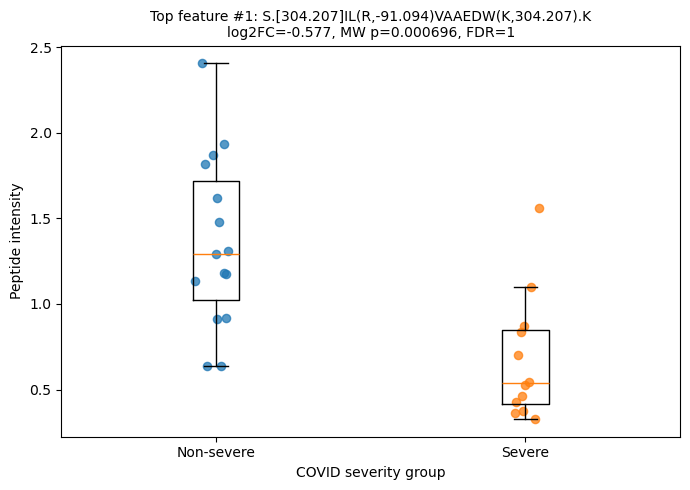

/var/folders/mg/l2trns2n14g4lgj2qbv0lslm0000gn/T/ipykernel_45731/3522600348.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(groups, labels=labels, showfliers=False)


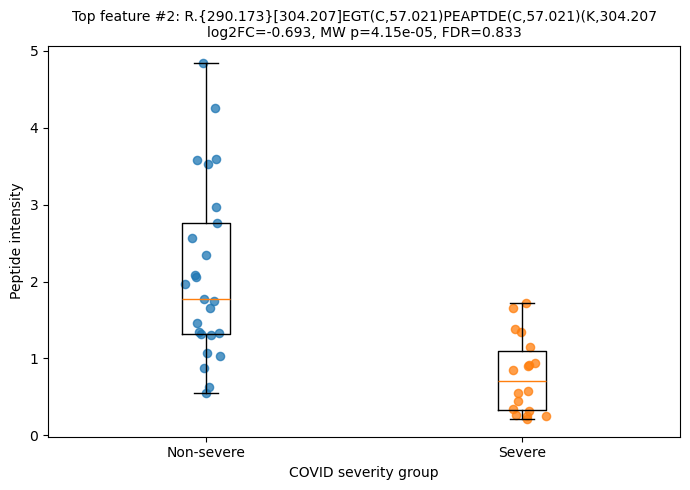

/var/folders/mg/l2trns2n14g4lgj2qbv0lslm0000gn/T/ipykernel_45731/3522600348.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(groups, labels=labels, showfliers=False)


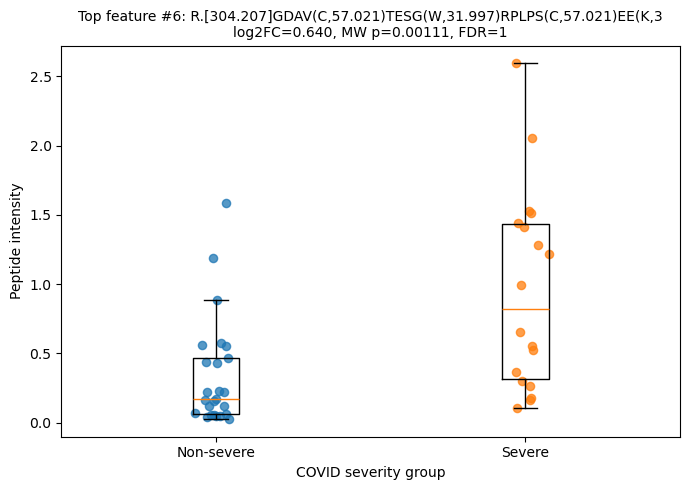

In [6]:
def plot_peptide_intensity(peptide, rank):
    plot_df = pd.DataFrame({
        "Condition": condition,
        "Intensity": X[peptide]
    }).dropna()

    groups = [
        plot_df.loc[plot_df["Condition"] == "Non-severe-COVID-19", "Intensity"],
        plot_df.loc[plot_df["Condition"] == "Severe-COVID-19", "Intensity"]
    ]
    labels = ["Non-severe", "Severe"]

    fig, ax = plt.subplots(figsize=(7, 5))
    ax.boxplot(groups, labels=labels, showfliers=False)

    rng = np.random.default_rng(42)
    for i, vals in enumerate(groups, start=1):
        jitter = rng.normal(loc=i, scale=0.035, size=len(vals))
        ax.scatter(jitter, vals, alpha=0.75, s=35)

    stat = top_feature_stats.loc[top_feature_stats["Peptide"] == peptide].iloc[0]
    title = (
        f"Top feature #{rank}: {peptide[:60]}"
        f"\nlog2FC={stat['log2FC_median_severe_vs_nonsevere']:.3f}, "
        f"MW p={stat['mannwhitney_pvalue']:.3g}, FDR={stat['mannwhitney_fdr']:.3g}"
    )
    ax.set_title(title, fontsize=10)
    ax.set_ylabel("Peptide intensity")
    ax.set_xlabel("COVID severity group")
    plt.tight_layout()

    safe_name = f"top_feature_{rank}_intensity.png"
    fig.savefig(OUTPUT_DIR / safe_name, dpi=200, bbox_inches="tight")
    plt.show()

for _, row in selected_feature_stats.sort_values("model_rank").iterrows():
    plot_peptide_intensity(row["Peptide"], int(row["model_rank"]))

## 6. Modified variant vs same-sequence comparison

For each selected model feature (ranks 1, 2, and 6), this step strips modification annotations to infer the underlying amino-acid sequence. It then searches for other peptide variants with the same sequence.

If a completely unmodified form is present, that is the preferred comparison. If not, the notebook selects the least-modified alternative variant with the highest average observed intensity. This satisfies the rubric's fallback option of comparing against the most predominant variant of the same amino-acid sequence.

In [7]:
def strip_mods_to_sequence(peptide):
    """Return an approximate amino-acid sequence after removing mass annotations and flanking residues."""
    s = str(peptide)
    # Preserve the modified residue in patterns like (K,304.207), (S,304.212), (R,-91.094).
    s = re.sub(r"\(([A-Z]),\s*[-+]?\d+(?:\.\d+)?\)", r"\1", s)
    # Remove numeric-only bracket/brace annotations such as [304.207] or {290.173}.
    s = re.sub(r"\[\s*[-+]?\d+(?:\.\d+)?\s*\]", "", s)
    s = re.sub(r"\{\s*[-+]?\d+(?:\.\d+)?\s*\}", "", s)
    # Remove any remaining parenthetical numeric annotation.
    s = re.sub(r"\(\s*[-+]?\d+(?:\.\d+)?\s*\)", "", s)
    # Remove simple flanking residues after numeric cleanup, e.g. K.PEPTIDE.R -> PEPTIDE.
    if re.match(r"^[A-Z]\.([A-Z]+)\.[A-Z]$", s):
        s = s.split(".")[1]
    # Keep only uppercase amino-acid letters.
    return "".join(re.findall(r"[A-Z]", s))

def modification_count(peptide):
    s = str(peptide)
    # Count mass annotations. This includes fixed labels such as TMT or carbamidomethylation.
    return len(re.findall(r"\[[^\]]+\]|\{[^\}]+\}|\([A-Z]?,?\s*[-+]?\d+(?:\.\d+)?\)", s))

peptide_meta = pd.DataFrame({"Peptide": X.columns})
peptide_meta["base_sequence"] = peptide_meta["Peptide"].map(strip_mods_to_sequence)
peptide_meta["modification_count"] = peptide_meta["Peptide"].map(modification_count)
peptide_meta["mean_observed_intensity"] = X.mean(axis=0, skipna=True).values
peptide_meta["observed_count"] = X.notna().sum(axis=0).values

comparison_rows = []
for _, row in selected_feature_stats.sort_values("model_rank").iterrows():
    peptide = row["Peptide"]
    base_seq = strip_mods_to_sequence(peptide)
    candidates = peptide_meta[(peptide_meta["base_sequence"] == base_seq) & (peptide_meta["Peptide"] != peptide)].copy()

    if candidates.empty:
        comparison_rows.append({
            "model_rank": int(row["model_rank"]),
            "top_feature_peptide": peptide,
            "base_sequence": base_seq,
            "comparison_peptide": np.nan,
            "comparison_type": "no same-sequence alternative found",
        })
        continue

    candidates = candidates.sort_values(["modification_count", "mean_observed_intensity"], ascending=[True, False])
    comp = candidates.iloc[0]
    comp_stats = stats_df.loc[stats_df["Peptide"] == comp["Peptide"]].iloc[0]

    top_mod_count = modification_count(peptide)
    comparison_type = "least-modified same-sequence variant"
    if comp["modification_count"] == 0:
        comparison_type = "unmodified same-sequence variant"
    elif comp["modification_count"] < top_mod_count:
        comparison_type = "less-modified same-sequence variant"
    else:
        comparison_type = "most abundant same-sequence alternative variant"

    comparison_rows.append({
        "top_feature_peptide": peptide,
        "base_sequence": base_seq,
        "top_feature_modification_count": top_mod_count,
        "top_feature_log2FC": row["log2FC_median_severe_vs_nonsevere"],
        "top_feature_mannwhitney_pvalue": row["mannwhitney_pvalue"],
        "top_feature_mannwhitney_fdr": row["mannwhitney_fdr"],
        "comparison_peptide": comp["Peptide"],
        "comparison_type": comparison_type,
        "comparison_modification_count": comp["modification_count"],
        "comparison_log2FC": comp_stats["log2FC_median_severe_vs_nonsevere"],
        "comparison_mannwhitney_pvalue": comp_stats["mannwhitney_pvalue"],
        "comparison_mannwhitney_fdr": comp_stats["mannwhitney_fdr"],
    })

variant_comparison = pd.DataFrame(comparison_rows)
variant_comparison.to_csv(OUTPUT_DIR / "modified_vs_same_sequence_variant_comparison.tsv", sep="\t", index=False)
display(variant_comparison)

,top_feature_peptide,base_sequence,top_feature_modification_count,top_feature_log2FC,top_feature_mannwhitney_pvalue,top_feature_mannwhitney_fdr,comparison_peptide,comparison_type,comparison_modification_count,comparison_log2FC,comparison_mannwhitney_pvalue,comparison_mannwhitney_fdr
0,"S.[304.207]IL(R,-91.094)VAAEDW(K,304.207).K",ILRVAAEDWK,3,-0.576559,0.000696,1.000000,"S.[304.207](I,21.904)LRVAAEDW(K,304.207).K",most abundant same-sequence alternative variant,3,NaN,NaN,NaN
1,"R.{290.173}[304.207]EGT(C,57.021)PEAPTDE(C,57....",EGTCPEAPTDECKPVK,6,-0.692628,0.000042,0.832764,"R.[304.207]EGT(C,-18.985)PEAPTDE(C,57.021)(K,3...",less-modified same-sequence variant,5,NaN,NaN,NaN
2,"R.[304.207]GDAV(C,57.021)TESG(W,31.997)RPLPS(C...",GDAVCTESGWRPLPSCEEK,5,0.640026,0.001107,1.000000,"R.[304.207]GDAV(C,57.021)TESGWRPLPS(C,57.021)E...",less-modified same-sequence variant,4,NaN,NaN,NaN


## 7. Auto-generate short interpretation text for ranks 1, 2, and 6

Use this as a starting point for the report. Edit the peptide names and conclusions based on the final table values.

In [ ]:
lines = []
for _, row in selected_feature_stats.sort_values("model_rank").iterrows():
    pep = row["Peptide"]
    missing = max(row["missing_pct_severe"], row["missing_pct_nonsevere"])
    lines.append(
        f"Model-ranked peptide #{int(row['model_rank'])} ({pep}) had {row['da_direction'].lower()} "
        f"(median log2FC = {row['log2FC_median_severe_vs_nonsevere']:.3f}; "
        f"Mann-Whitney p = {row['mannwhitney_pvalue']:.3g}; "
        f"FDR = {row['mannwhitney_fdr']:.3g}). "
        f"The maximum group-specific missingness was {missing:.1f}%, classified as {row['missingness_flag']}."
    )

report_text = "\n\n".join(lines)
print(report_text)

with open(OUTPUT_DIR / "peptide_differentials_report_text_draft.txt", "w") as f:
    f.write(report_text)

Model-ranked peptide #1 (S.[304.207]IL(R,-91.094)VAAEDW(K,304.207).K) had higher median intensity in non-severe (median log2FC = -0.577; Mann-Whitney p = 0.000696; FDR = 1). The maximum group-specific missingness was 40.0%, classified as moderate missingness.

Model-ranked peptide #2 (R.{290.173}[304.207]EGT(C,57.021)PEAPTDE(C,57.021)(K,304.207)PV(K,304.207).W) had higher median intensity in non-severe (median log2FC = -0.693; Mann-Whitney p = 4.15e-05; FDR = 0.833). The maximum group-specific missingness was 0.0%, classified as low missingness.

Model-ranked peptide #6 (R.[304.207]GDAV(C,57.021)TESG(W,31.997)RPLPS(C,57.021)EE(K,304.207).S) had higher median intensity in severe (median log2FC = 0.640; Mann-Whitney p = 0.00111; FDR = 1). The maximum group-specific missingness was 0.0%, classified as low missingness.


## 8. Files produced

After running the notebook, the following files will be saved in `peptide_differentials/`:

- `top_model_features.tsv`
- `all_peptide_differential_abundance.tsv`
- `peptide_differentials_top_model_feature_stats.tsv`
- `peptide_differentials_selected_rank_1_2_6_feature_stats.tsv`
- `modified_vs_same_sequence_variant_comparison.tsv`
- `top_feature_1_intensity.png`, `top_feature_2_intensity.png`, `top_feature_6_intensity.png`
- `peptide_differentials_report_text_draft.txt`